In [12]:
# type: ignore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('ai_job_market.csv')

df[['min_sal', 'max_sal']] = df['salary_range_usd'].str.split('-', expand=True).astype(float)
df['salary'] = (df['min_sal'] + df['max_sal']) / 2
df['posted_date'] = pd.to_datetime(df['posted_date'])

print(f"✓ Loaded {len(df)} jobs | Salary range: ${df['salary'].min():,.0f} - ${df['salary'].max():,.0f}")

✓ Loaded 2000 jobs | Salary range: $47,578 - $197,776


## 1. Tổng Quan Thị Trường

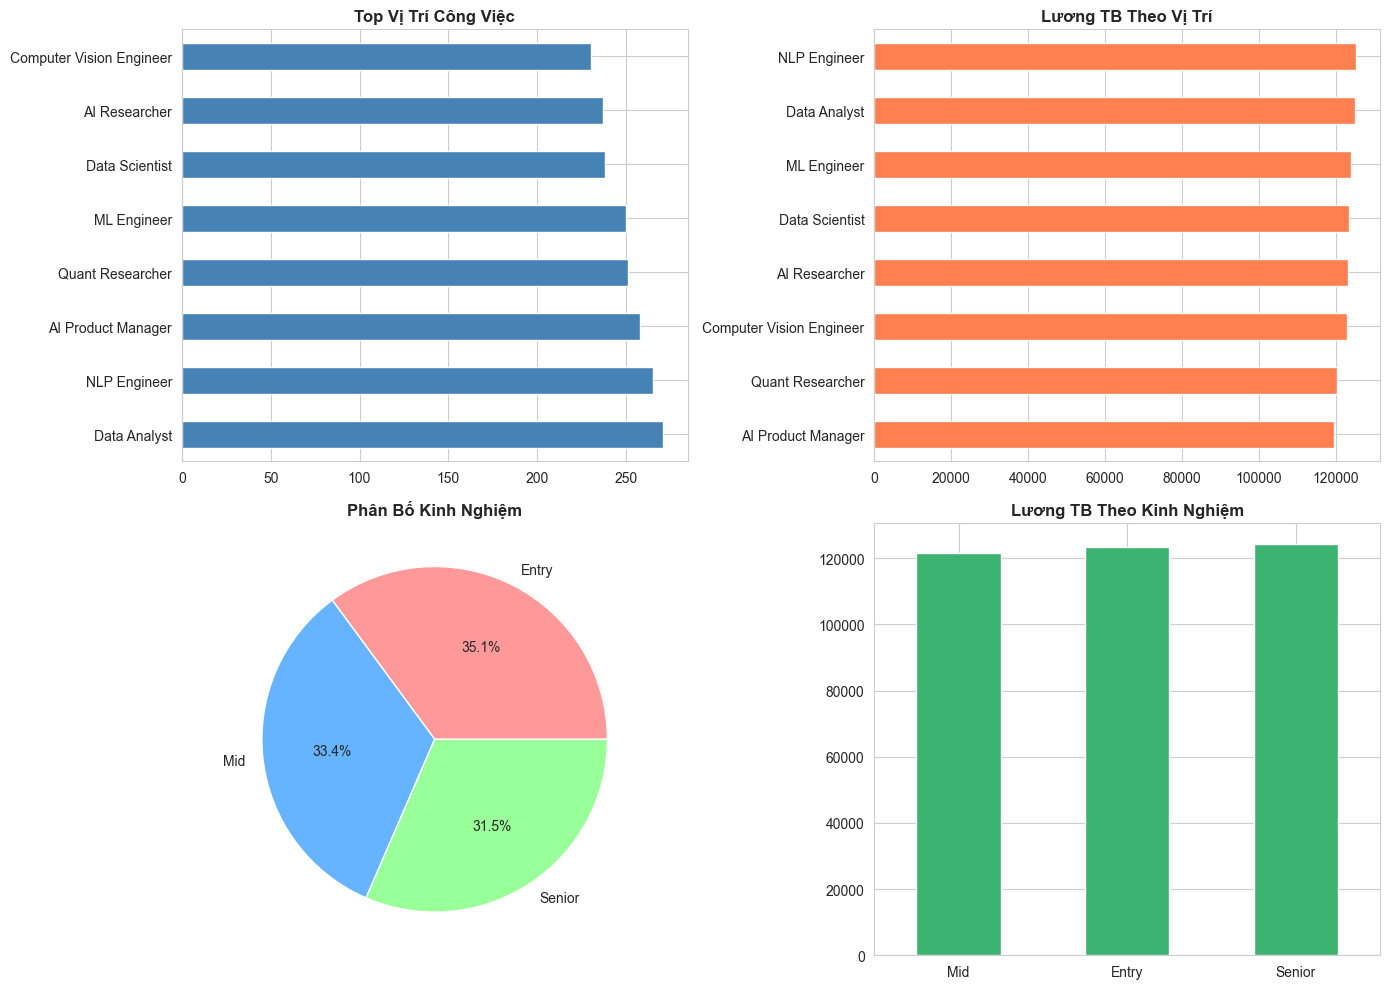

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['job_title'].value_counts().head(8).plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Top Vị Trí Công Việc', fontweight='bold')
axes[0,0].set_ylabel('')  

df.groupby('job_title')['salary'].mean().sort_values().tail(8).plot(kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('Lương TB Theo Vị Trí', fontweight='bold')
axes[0,1].set_ylabel('') 

df['experience_level'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
axes[1,0].set_title('Phân Bố Kinh Nghiệm', fontweight='bold')
axes[1,0].set_ylabel('')  

df.groupby('experience_level')['salary'].mean().sort_values().plot(kind='bar', ax=axes[1,1], color='mediumseagreen')
axes[1,1].set_title('Lương TB Theo Kinh Nghiệm', fontweight='bold')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 2. Phân Tích Ngành & Loại Công Việc

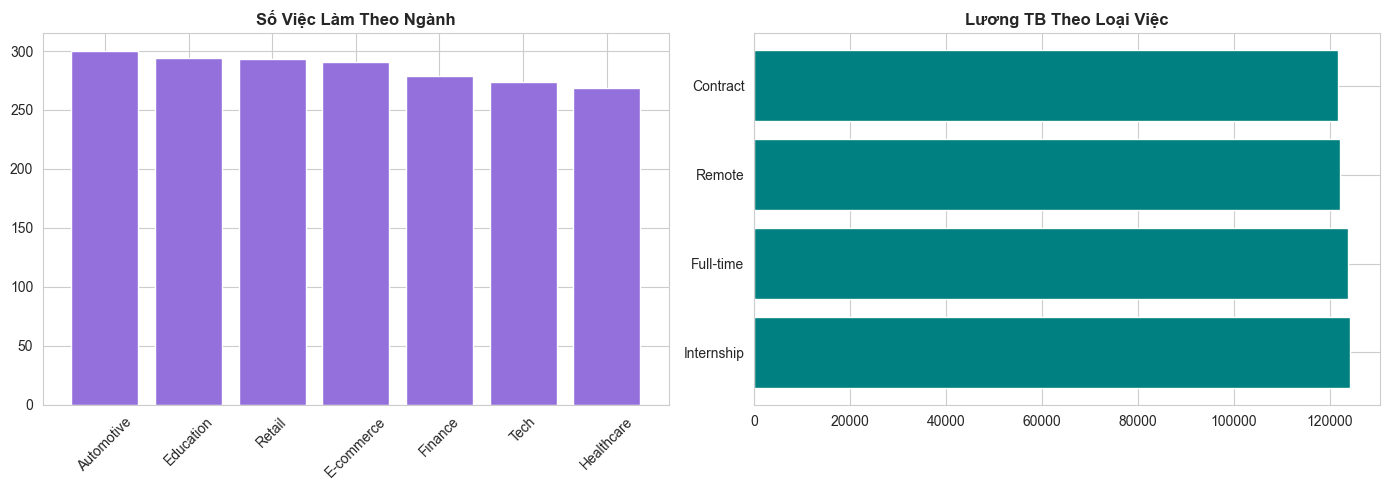

Thống kê theo ngành:
            Số việc  Lương TB
industry                     
Automotive      300  124546.0
Education       294  121797.0
Retail          293  122791.0
E-commerce      291  124745.0
Finance         279  123040.0
Tech            274  123217.0
Healthcare      269  120964.0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ind_data = df.groupby('industry')['salary'].agg(['count', 'mean']).sort_values('count', ascending=False)
axes[0].bar(ind_data.index, ind_data['count'], color='mediumpurple')
axes[0].set_title('Số Việc Làm Theo Ngành', fontweight='bold')
axes[0].set_xlabel('') 
axes[0].tick_params(axis='x', rotation=45)

emp_data = df.groupby('employment_type')['salary'].agg(['count', 'mean']).sort_values('mean', ascending=False)
axes[1].barh(emp_data.index, emp_data['mean'], color='teal')
axes[1].set_title('Lương TB Theo Loại Việc', fontweight='bold')
axes[1].set_ylabel('') 

plt.tight_layout()
plt.show()

print("Thống kê theo ngành:")
print(ind_data.rename(columns={'count': 'Số việc', 'mean': 'Lương TB'}).round(0))

## 3. Phân Tích Kỹ Năng

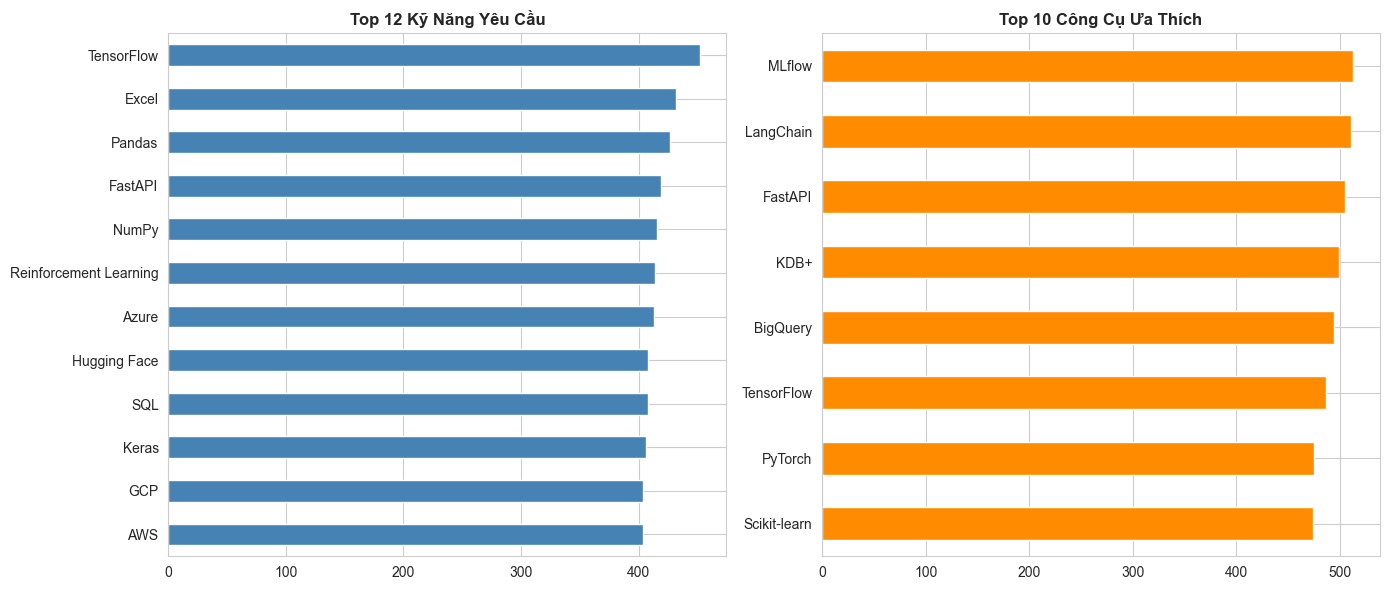

Top 5 kỹ năng: TensorFlow, Excel, Pandas, FastAPI, NumPy
Top 5 tools: MLflow, LangChain, FastAPI, KDB+, BigQuery


In [15]:
all_skills = [s.strip() for skills in df['skills_required'].dropna() for s in skills.split(',')]
all_tools = [t.strip() for tools in df['tools_preferred'].dropna() for t in tools.split(',')]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_skills = pd.Series(Counter(all_skills)).sort_values(ascending=True).tail(12)
top_skills.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 12 Kỹ Năng Yêu Cầu', fontweight='bold')

top_tools = pd.Series(Counter(all_tools)).sort_values(ascending=True).tail(10)
top_tools.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 10 Công Cụ Ưa Thích', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Top 5 kỹ năng: {', '.join(top_skills.tail(5).index.tolist()[::-1])}")
print(f"Top 5 tools: {', '.join(top_tools.tail(5).index.tolist()[::-1])}")

## 4. Heatmap Lương

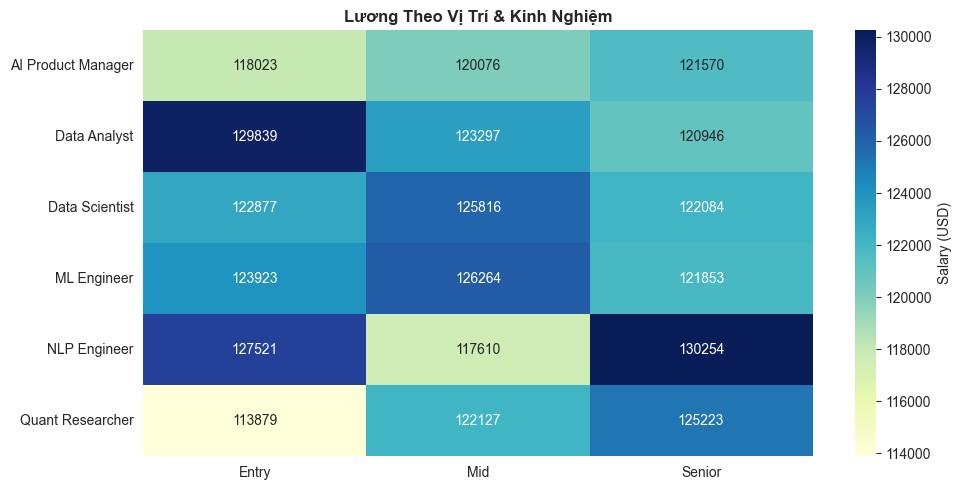

In [16]:
top_jobs = df['job_title'].value_counts().head(6).index
pivot = df[df['job_title'].isin(top_jobs)].pivot_table(
    values='salary', index='job_title', columns='experience_level', aggfunc='mean'
)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Salary (USD)'})
plt.title('Lương Theo Vị Trí & Kinh Nghiệm', fontweight='bold')
plt.xlabel('')  
plt.ylabel('')  
plt.tight_layout()
plt.show()

## 5. Dự Đoán Lương (ML)

Model Performance:
R² Score: -0.262 (-26.2% variance explained)
MAE: $33,129


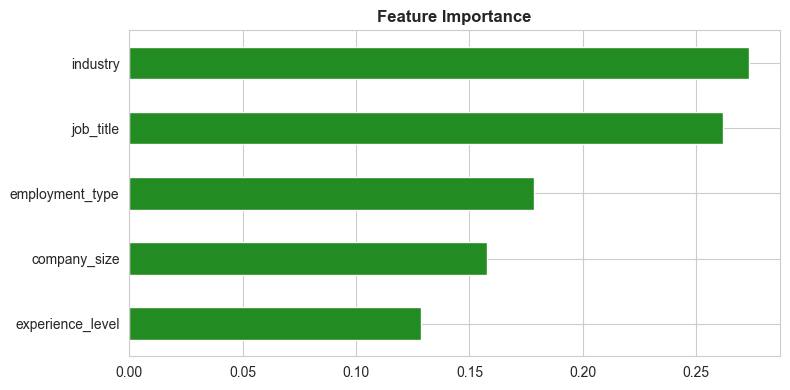

In [17]:
df_ml = df.copy()
features = ['job_title', 'experience_level', 'employment_type', 'industry', 'company_size']
encoders = {}

for col in features:
    encoders[col] = LabelEncoder()
    df_ml[col + '_enc'] = encoders[col].fit_transform(df_ml[col])

X = df_ml[[f + '_enc' for f in features]]
y = df_ml['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Model Performance:")
print(f"R² Score: {r2:.3f} ({r2*100:.1f}% variance explained)")
print(f"MAE: ${mae:,.0f}")

importance = pd.Series(model.feature_importances_, index=features).sort_values()
plt.figure(figsize=(8, 4))
importance.plot(kind='barh', color='forestgreen')
plt.title('Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:

def predict_salary(job, exp, emp_type, industry, size):
    try:
        x = [[encoders['job_title'].transform([job])[0],
              encoders['experience_level'].transform([exp])[0],
              encoders['employment_type'].transform([emp_type])[0],
              encoders['industry'].transform([industry])[0],
              encoders['company_size'].transform([size])[0]]]
        return model.predict(x)[0]
    except: return None

print("Dự đoán lương:")
tests = [
    ('Data Scientist', 'Senior', 'Full-time', 'Tech', 'Large'),
    ('ML Engineer', 'Mid', 'Full-time', 'Finance', 'Large'),
    ('Data Analyst', 'Entry', 'Full-time', 'Healthcare', 'Mid'),
]
for job, exp, emp, ind, size in tests:
    sal = predict_salary(job, exp, emp, ind, size)
    if sal: print(f"   {job} ({exp}): ${sal:,.0f}")

🔮 Dự đoán lương:
   Data Scientist (Senior): $152,487
   ML Engineer (Mid): $116,031
   Data Analyst (Entry): $106,926


## 6. Kết Luận

In [19]:
print("=" * 60)
print("KẾT LUẬN - THỊ TRƯỜNG VIỆC LÀM AI")
print("=" * 60)

print("\nTOP VỊ TRÍ:")
for i, (job, cnt) in enumerate(df['job_title'].value_counts().head(3).items(), 1):
    sal = df[df['job_title']==job]['salary'].mean()
    print(f"   {i}. {job}: {cnt} việc, ${sal:,.0f}")

# Top skills
print(f"\nKỸ NĂNG CẦN HỌC: {', '.join(top_skills.tail(5).index.tolist()[::-1])}")

# Salary insights
print(f"\nLƯƠNG:")
print(f"   Trung bình: ${df['salary'].mean():,.0f}")
print(f"   Entry → Senior tăng: {(df[df['experience_level']=='Senior']['salary'].mean() / df[df['experience_level']=='Entry']['salary'].mean() - 1)*100:.0f}%")

# Recommendations
print(f"\nKHUYẾN CÁO:")
print("   Học Python, SQL, Machine Learning")
print("   Nhắm ngành Tech/Finance (lương cao)")
print("   Phát triển lên Senior (+30% lương)")
print("=" * 60)

KẾT LUẬN - THỊ TRƯỜNG VIỆC LÀM AI

TOP VỊ TRÍ:
   1. Data Analyst: 271 việc, $125,101
   2. NLP Engineer: 265 việc, $125,308
   3. AI Product Manager: 258 việc, $119,715

KỸ NĂNG CẦN HỌC: TensorFlow, Excel, Pandas, FastAPI, NumPy

LƯƠNG:
   Trung bình: $123,040
   Entry → Senior tăng: 1%

KHUYẾN CÁO:
   Học Python, SQL, Machine Learning
   Nhắm ngành Tech/Finance (lương cao)
   Phát triển lên Senior (+30% lương)
